In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

In [3]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

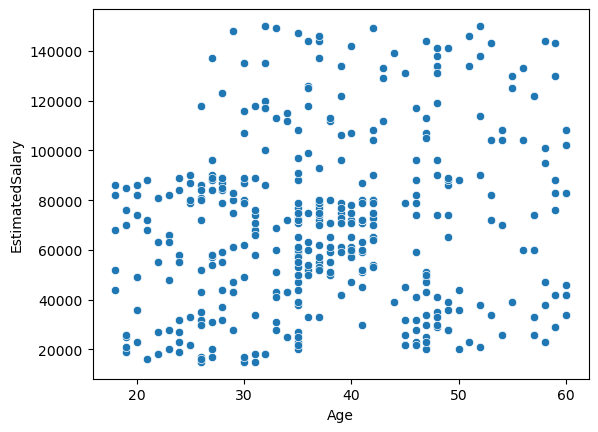

In [4]:
import seaborn as sns
sns.scatterplot(x = "Age" , y = "EstimatedSalary" , data = df)

In [5]:
x = df.drop("Purchased" , axis =1)
y = df.Purchased

In [6]:
from sklearn.model_selection import train_test_split
x_train ,x_test , y_train ,y_test = train_test_split(x,y , test_size = .2 , random_state = 42) 

In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential

In [8]:
model = Sequential()

model.add(Dense(128 , activation = "relu" , input_dim = 2))
model.add(Dense(1 , activation = "sigmoid"))

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               384       
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 513 (2.00 KB)
Trainable params: 513 (2.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
model.compile(loss = "binary_crossentropy" , optimizer = "adam" , metrics = ["accuracy"])

In [11]:
history = model.fit(x_train , y_train , validation_data = (x_test , y_test) ,epochs = 100)

Epoch 1/100


10/10 [==============================] - 1s 36ms/step - loss: 891.7660 - accuracy: 0.4719 - val_loss: 422.0473 - val_accuracy: 0.3500
Epoch 2/100
10/10 [==============================] - 0s 6ms/step - loss: 404.5584 - accuracy: 0.5781 - val_loss: 149.3017 - val_accuracy: 0.6500
Epoch 3/100
10/10 [==============================] - 0s 5ms/step - loss: 118.7325 - accuracy: 0.4594 - val_loss: 88.9750 - val_accuracy: 0.3500
Epoch 4/100
10/10 [==============================] - 0s 7ms/step - loss: 38.5953 - accuracy: 0.4719 - val_loss: 24.0063 - val_accuracy: 0.6500
Epoch 5/100
10/10 [==============================] - 0s 7ms/step - loss: 37.7080 - accuracy: 0.5719 - val_loss: 110.6338 - val_accuracy: 0.3500
Epoch 6/100
10/10 [==============================] - 0s 7ms/step - loss: 81.4003 - accuracy: 0.5344 - val_loss: 34.9809 - val_accuracy: 0.3500
Epoch 7/100
10/10 [==============================] - 0s 7ms/step - loss: 72.7800 - accuracy: 0.5094 - val_loss: 85.7386 - val_accurac

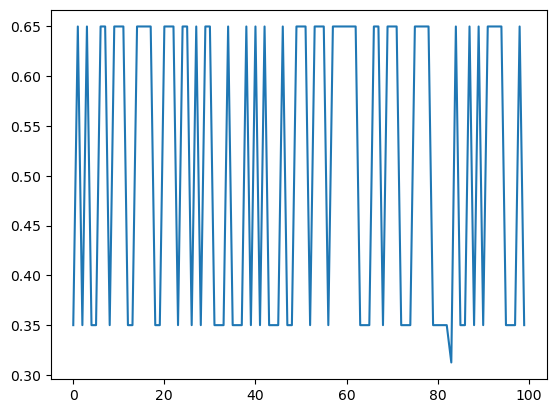

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

# applying scaling

In [14]:
from sklearn.preprocessing import StandardScaler
scl = StandardScaler()

In [15]:
x_trained_scaled = scl.fit_transform(x_train)
x_test_scaled = scl.transform(x_test)

In [16]:
model1 = Sequential()
model1.add(Dense(128 , activation = "relu" , input_dim = 2))
model1.add(Dense(1 , activation = "sigmoid"))

In [17]:
model1.compile(loss = "binary_crossentropy" , optimizer = "adam" , metrics = ["accuracy"])

In [18]:
model1.fit(x_trained_scaled , y_train , validation_data = (x_test_scaled , y_test) , epochs = 100)

Epoch 1/100
10/10 [==============================] - 1s 26ms/step - loss: 0.7353 - accuracy: 0.3125 - val_loss: 0.7149 - val_accuracy: 0.3125
Epoch 2/100
10/10 [==============================] - 0s 6ms/step - loss: 0.6802 - accuracy: 0.5375 - val_loss: 0.6495 - val_accuracy: 0.7625
Epoch 3/100
10/10 [==============================] - 0s 6ms/step - loss: 0.6318 - accuracy: 0.7875 - val_loss: 0.5960 - val_accuracy: 0.8250
Epoch 4/100
10/10 [==============================] - 0s 6ms/step - loss: 0.5927 - accuracy: 0.8250 - val_loss: 0.5496 - val_accuracy: 0.8500
Epoch 5/100
10/10 [==============================] - 0s 6ms/step - loss: 0.5594 - accuracy: 0.8375 - val_loss: 0.5092 - val_accuracy: 0.8750
Epoch 6/100
10/10 [==============================] - 0s 5ms/step - loss: 0.5303 - accuracy: 0.8438 - val_loss: 0.4732 - val_accuracy: 0.8625
Epoch 7/100
10/10 [==============================] - 0s 7ms/step - loss: 0.5025 - accuracy: 0.8375 - val_loss: 0.4424 - val_accuracy: 0.8500
Epoch 8/100
